In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# --- NLTK for Text Preprocessing ---
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- Scikit-learn for Traditional ML ---
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils import class_weight

# --- TensorFlow and Keras for Deep Learning ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, TextVectorization
from tensorflow.keras.callbacks import EarlyStopping

# --- Transformers for Fine-tuning ---
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

print("All libraries imported successfully.")

2025-07-27 06:59:21.866016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753599562.221798      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753599562.329852      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


All libraries imported successfully.


In [3]:
# Cell 2
# NLTK setup for preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("NLTK packages downloaded and random seeds set.")

NLTK packages downloaded and random seeds set.


In [4]:
# Cell 3
print("Loading dataset from pre-defined splits...")
splits = {
    'train': 'data/train-00000-of-00001-138b53eb17a3e862.parquet',
    'validation': 'data/validation-00000-of-00001-0876be41e3ab7acd.parquet',
    'test': 'data/test-00000-of-00001-41c7ea948573445f.parquet'
}

try:
    train_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["train"])
    val_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["validation"])
    test_df = pd.read_parquet("hf://datasets/atrost/financial_phrasebank/" + splits["test"])
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"Could not load data from Hugging Face Hub. Error: {e}")
    print("Please ensure you have `pyarrow` and `fsspec` installed (`pip install pyarrow fsspec`).")

Loading dataset from pre-defined splits...
Dataset loaded successfully.


In [5]:
# Split the data into features (X) and labels (y)
X_train, y_train = train_df['sentence'], train_df['label']
X_val, y_val = val_df['sentence'], val_df['label']
X_test, y_test = test_df['sentence'], test_df['label']

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# Map numeric labels to human-readable names
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

Training set size: 3100
Validation set size: 776
Test set size: 970


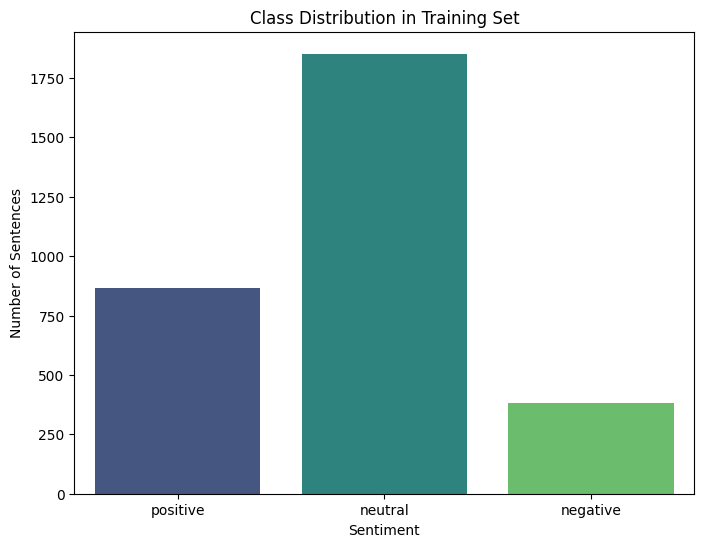

EDA shows a significant class imbalance, with 'neutral' being the majority class.


In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x=train_df['label'].map(label_map), palette='viridis', order=['positive', 'neutral', 'negative'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Sentiment')
plt.ylabel('Number of Sentences')
plt.show()

print("EDA shows a significant class imbalance, with 'neutral' being the majority class.")

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join([word for word in text.split() if word not in stop_words])
    text = ' '.join([lemmatizer.lemmatize(word) for word in text.split()])
    return text

print("Preprocessing function defined.")

Preprocessing function defined.


In [8]:
# Cell 7
print("Preprocessing text for traditional models...")
X_train_trad = X_train.apply(preprocess_text)
X_test_trad = X_test.apply(preprocess_text)
print("Preprocessing complete.")
print("\nExample of original text:")
print(X_train.iloc[0])
print("\nExample of preprocessed text:")
print(X_train_trad.iloc[0])

Preprocessing text for traditional models...
Preprocessing complete.

Example of original text:
EBIT margin was up from 1.4 % to 5.1 % .

Example of preprocessed text:
ebit margin


In [9]:
# Cell 8
print("Establishing a baseline...")
majority_class = y_train.mode()[0]
baseline_predictions = [majority_class] * len(y_test)
baseline_accuracy = accuracy_score(y_test, baseline_predictions)

print(f"Majority Class: {label_map[majority_class]}")
print(f"Baseline (Majority Class) Accuracy on Test Set: {baseline_accuracy:.4f}")
print("\nThis is the score our models must significantly beat.")

# Initialize a dictionary to store results
results = {}

Establishing a baseline...
Majority Class: neutral
Baseline (Majority Class) Accuracy on Test Set: 0.5825

This is the score our models must significantly beat.


In [10]:
# Cell 9
print("--- Step 1: Manual Feature Engineering with TF-IDF ---")
vectorizer = TfidfVectorizer(ngram_range=(1, 2))

# Learn vocabulary and transform training data
X_train_vec = vectorizer.fit_transform(X_train_trad)

# Transform test data using the learned vocabulary
X_test_vec = vectorizer.transform(X_test_trad)

print(f"Shape of the training data matrix: {X_train_vec.shape}")
print(f"Shape of the test data matrix: {X_test_vec.shape}")

--- Step 1: Manual Feature Engineering with TF-IDF ---
Shape of the training data matrix: (3100, 32020)
Shape of the test data matrix: (970, 32020)


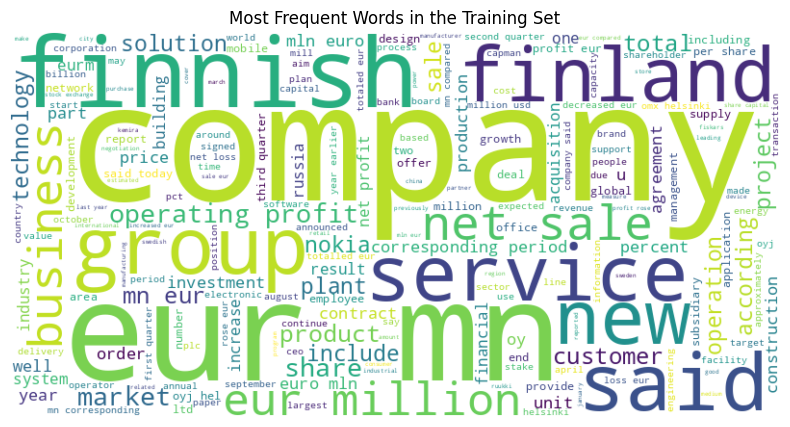

In [11]:
# In SECTION 2, after the preprocessing step

from wordcloud import WordCloud

# Join all the preprocessed training text into a single string
full_text = ' '.join(X_train_trad.tolist())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(full_text)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in the Training Set")
plt.show()

In [12]:
# Cell 10
print("--- Manually Finetuning Model 1: Multinomial Naive Bayes ---")
alphas_to_test = [0.01, 0.1, 1.0, 5.0]
best_alpha = None
best_score_nb = -1

print("Searching for the best 'alpha' hyperparameter...")
for alpha in alphas_to_test:
    model_nb = MultinomialNB(alpha=alpha)
    model_nb.fit(X_train_vec, y_train)
    y_pred_nb_current = model_nb.predict(X_test_vec)
    current_score = f1_score(y_test, y_pred_nb_current, average='macro')
    print(f"  Tested alpha = {alpha:<4} | Macro F1-Score = {current_score:.4f}")
    if current_score > best_score_nb:
        best_score_nb = current_score
        best_alpha = alpha

print(f"\nBest 'alpha' found: {best_alpha}")

--- Manually Finetuning Model 1: Multinomial Naive Bayes ---
Searching for the best 'alpha' hyperparameter...
  Tested alpha = 0.01 | Macro F1-Score = 0.6080
  Tested alpha = 0.1  | Macro F1-Score = 0.5693
  Tested alpha = 1.0  | Macro F1-Score = 0.3919
  Tested alpha = 5.0  | Macro F1-Score = 0.3185

Best 'alpha' found: 0.01


Training final Naive Bayes model with the best alpha...

Final Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.64      0.51      0.57       125
     neutral       0.73      0.80      0.76       565
    positive       0.52      0.46      0.49       280

    accuracy                           0.67       970
   macro avg       0.63      0.59      0.61       970
weighted avg       0.66      0.67      0.66       970



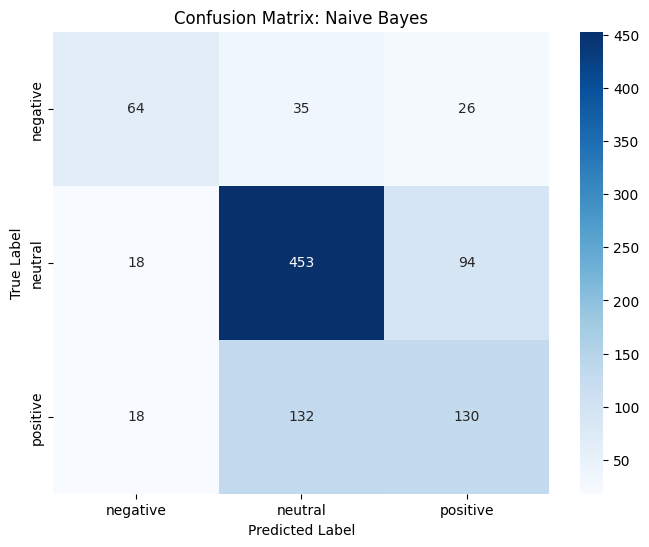

In [13]:
# Cell 11
# A helper function to plot confusion matrices, will be used by all models
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=list(label_map.keys()))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_map.values(), yticklabels=label_map.values())
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

print("Training final Naive Bayes model with the best alpha...")
final_model_nb = MultinomialNB(alpha=best_alpha)
final_model_nb.fit(X_train_vec, y_train)
y_pred_nb_final = final_model_nb.predict(X_test_vec)

print("\nFinal Naive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb_final, target_names=label_map.values()))
plot_confusion_matrix(y_test, y_pred_nb_final, "Confusion Matrix: Naive Bayes")
results['Naive Bayes'] = f1_score(y_test, y_pred_nb_final, average='macro')

In [14]:
# Cell 12
print("--- Manually Finetuning Model 2: Support Vector Machine (SVM) ---")
C_values_to_test = [0.1, 1, 10]
best_C = None
best_score_svm = -1

print("Searching for the best 'C' hyperparameter...")
for C_val in C_values_to_test:
    model_svm = SVC(random_state=42, C=C_val, kernel='linear', class_weight='balanced')
    model_svm.fit(X_train_vec, y_train)
    y_pred_svm_current = model_svm.predict(X_test_vec)
    current_score = f1_score(y_test, y_pred_svm_current, average='macro')
    print(f"  Tested C = {C_val:<4} | Macro F1-Score = {current_score:.4f}")
    if current_score > best_score_svm:
        best_score_svm = current_score
        best_C = C_val

print(f"\nBest 'C' value found: {best_C}")

--- Manually Finetuning Model 2: Support Vector Machine (SVM) ---
Searching for the best 'C' hyperparameter...
  Tested C = 0.1  | Macro F1-Score = 0.4736
  Tested C = 1    | Macro F1-Score = 0.6763
  Tested C = 10   | Macro F1-Score = 0.6574

Best 'C' value found: 1


Training final SVM model with the best C value...

Final SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.65      0.59      0.62       125
     neutral       0.78      0.81      0.79       565
    positive       0.62      0.60      0.61       280

    accuracy                           0.72       970
   macro avg       0.69      0.67      0.68       970
weighted avg       0.72      0.72      0.72       970



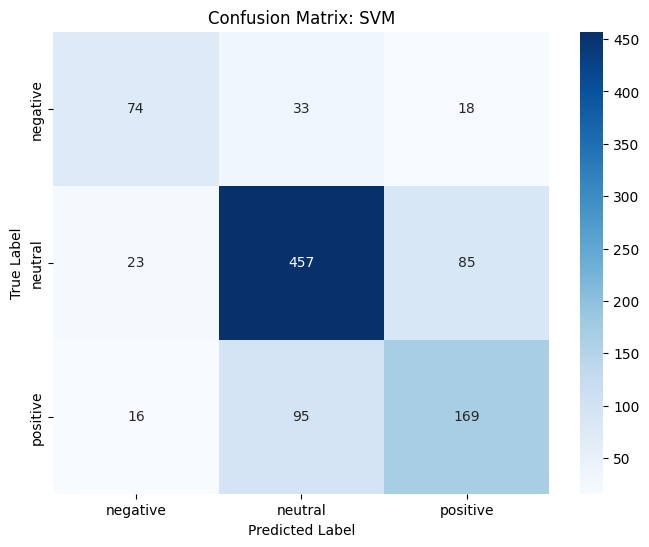

In [15]:
# Cell 13
print("Training final SVM model with the best C value...")
final_model_svm = SVC(random_state=42, C=best_C, kernel='linear', class_weight='balanced')
final_model_svm.fit(X_train_vec, y_train)
y_pred_svm_final = final_model_svm.predict(X_test_vec)

print("\nFinal SVM Classification Report:")
print(classification_report(y_test, y_pred_svm_final, target_names=label_map.values()))
plot_confusion_matrix(y_test, y_pred_svm_final, "Confusion Matrix: SVM")
results['SVM'] = f1_score(y_test, y_pred_svm_final, average='macro')

In [16]:
# Cell 14
print("--- Setting up preprocessing for LSTM Model ---")
MAX_FEATURES = 10000  # Maximum vocabulary size
MAX_LEN = 128         # Max sequence length

vectorizer_dl = TextVectorization(max_tokens=MAX_FEATURES,
                                  output_sequence_length=MAX_LEN,
                                  standardize='lower_and_strip_punctuation')
# Learn the vocabulary from the raw training text
vectorizer_dl.adapt(X_train.values)
print("TextVectorization layer adapted to training data.")

--- Setting up preprocessing for LSTM Model ---
TextVectorization layer adapted to training data.


I0000 00:00:1753599606.232040      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1753599606.232947      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [17]:
# Cell 15
print("--- Defining the LSTM Model Architecture ---")
model_lstm = Sequential([
    vectorizer_dl,
    Embedding(input_dim=MAX_FEATURES + 1, output_dim=256),
    Bidirectional(LSTM(128, dropout=0.5)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_lstm.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

--- Defining the LSTM Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Cell 16 (Corrected using tf.data.Dataset)

print("\n--- Preparing Data and Training the LSTM Model ---")

# --- Step 1: Create the class weight dictionary (this part is correct now) ---
from sklearn.utils import class_weight

class_weights_np = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights_np)}
print(f"Using class weights for DL training: {class_weights_dict}")

# --- Step 2: Convert pandas Series to a tf.data.Dataset (THE NEW FIX) ---
# This is the standard, robust way to feed data to a TensorFlow model.
train_dataset_lstm = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_dataset_lstm = tf.data.Dataset.from_tensor_slices((X_val.values, y_val.values))

# --- Step 3: Batch and prefetch the dataset for performance ---
BATCH_SIZE = 32
# Shuffling the training data is crucial for good training
train_dataset_lstm = train_dataset_lstm.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset_lstm = val_dataset_lstm.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nData converted to tf.data.Dataset format.")

# --- Step 4: Train the model using the new dataset ---
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# The .fit() call now takes the dataset object directly.
history_lstm = model_lstm.fit(
    train_dataset_lstm,
    epochs=20,
    validation_data=val_dataset_lstm,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)


--- Preparing Data and Training the LSTM Model ---
Using class weights for DL training: {0: 2.7050610820244327, 1: 0.5579553635709144, 2: 1.193225558121632}

Data converted to tf.data.Dataset format.
Epoch 1/20


I0000 00:00:1753599614.974795      72 cuda_dnn.cc:529] Loaded cuDNN version 90300


97/97 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.4535 - loss: 1.0810 - val_accuracy: 0.6198 - val_loss: 0.8839
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.6598 - loss: 0.8675 - val_accuracy: 0.6830 - val_loss: 0.7877
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.8272 - loss: 0.5062 - val_accuracy: 0.6508 - val_loss: 0.8535
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9363 - loss: 0.2210 - val_accuracy: 0.6314 - val_loss: 1.0624
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9712 - loss: 0.1157 - val_accuracy: 0.7139 - val_loss: 0.9183
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9775 - loss: 0.0841 - val_accuracy: 0.6920 - val_loss: 1.3597
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9886 - loss: 0.0367 - val_accuracy: 0.6856 - val_loss: 1.3802
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9957 - loss: 0.0208 - val_accuracy: 0.7139 - val_loss: 1

--- Visualizing LSTM Training History ---


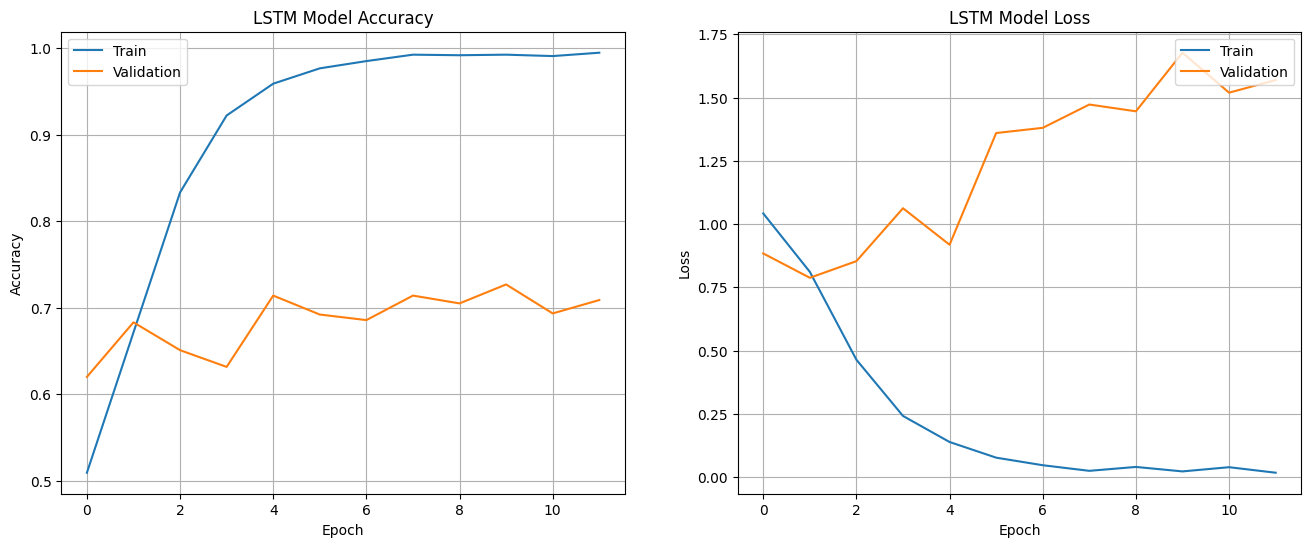

In [19]:
# Cell 12.5 (Insert after LSTM training)

print("--- Visualizing LSTM Training History ---")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training & validation accuracy values
ax1.plot(history_lstm.history['accuracy'])
ax1.plot(history_lstm.history['val_accuracy'])
ax1.set_title('LSTM Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')
ax1.grid(True)


# Plot training & validation loss values
ax2.plot(history_lstm.history['loss'])
ax2.plot(history_lstm.history['val_loss'])
ax2.set_title('LSTM Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper right')
ax2.grid(True)

plt.show()

# Based on the plots, we can discuss if the model overfitted and how EarlyStopping helped.
# For example, if val_loss started to increase after epoch 5, EarlyStopping would have
# restored the model weights from the end of epoch 5, giving us the best performing model.


--- Evaluating the LSTM Model ---
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

    negative       0.47      0.59      0.52       125
     neutral       0.71      0.84      0.77       565
    positive       0.57      0.29      0.39       280

    accuracy                           0.65       970
   macro avg       0.58      0.58      0.56       970
weighted avg       0.64      0.65      0.63       970



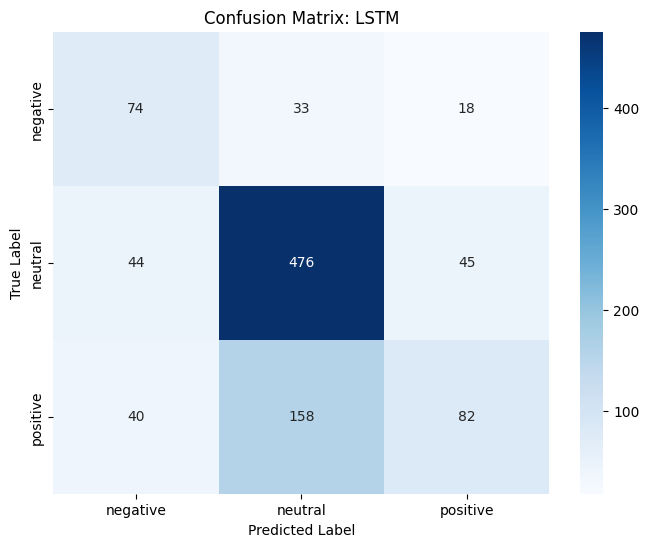

In [20]:
# Cell 17 (Corrected)
print("\n--- Evaluating the LSTM Model ---")

# --- Step 1: Convert the test data to the same tf.data.Dataset format ---
# We do not shuffle the test set. We just batch it.
test_dataset_lstm = tf.data.Dataset.from_tensor_slices(X_test.values)
test_dataset_lstm = test_dataset_lstm.batch(32).prefetch(tf.data.AUTOTUNE)

# --- Step 2: Predict using the batched dataset ---
y_pred_probs_lstm = model_lstm.predict(test_dataset_lstm)
y_pred_lstm = np.argmax(y_pred_probs_lstm, axis=1)

# --- Step 3: Evaluate the results (this part remains the same) ---
print("\nLSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=label_map.values()))
plot_confusion_matrix(y_test, y_pred_lstm, "Confusion Matrix: LSTM")
results['LSTM'] = f1_score(y_test, y_pred_lstm, average='macro')

In [21]:
# 1. Download GloVe 100d (run only once)
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip -o glove.6B.zip

# 2. Load GloVe Embeddings
import numpy as np

def load_glove_embeddings(glove_file_path, embedding_dim):
    embeddings_index = {}
    with open(glove_file_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    print(f'Loaded {len(embeddings_index)} word vectors from GloVe.')
    return embeddings_index

GLOVE_DIM = 100
glove_path = 'glove.6B.100d.txt'
embeddings_index = load_glove_embeddings(glove_path, GLOVE_DIM)

# 3. Build the Embedding Matrix
vocab = vectorizer_dl.get_vocabulary()
word_index = {word: idx for idx, word in enumerate(vocab)}
embedding_matrix = np.zeros((len(vocab), GLOVE_DIM))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

# 4. Plug GloVe Embedding into Your Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras import regularizers

embedding_layer = Embedding(
    input_dim=len(vocab),
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False  # Set True to finetune embeddings, False to keep them fixed
)

model_lstm_1 = Sequential([
    vectorizer_dl,
    embedding_layer,
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.4)),
    BatchNormalization(),
    Bidirectional(LSTM(64, dropout=0.4)),
    Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.002)),
    Dropout(0.6),
    Dense(3, activation='softmax')
])

model_lstm_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm_1.summary()


--2025-07-27 07:00:38--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-07-27 07:00:38--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-07-27 07:00:38--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 128)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ ?                      │       882,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,000 (3.36 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 882,000 (3.36 MB)

In [22]:
# Cell 16 (Corrected using tf.data.Dataset)

print("\n--- Preparing Data and Training the LSTM Model ---")

# --- Step 1: Create the class weight dictionary (this part is correct now) ---
from sklearn.utils import class_weight

class_weights_np = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: float(w) for i, w in enumerate(class_weights_np)}
print(f"Using class weights for DL training: {class_weights_dict}")

# --- Step 2: Convert pandas Series to a tf.data.Dataset (THE NEW FIX) ---
# This is the standard, robust way to feed data to a TensorFlow model.
train_dataset_lstm = tf.data.Dataset.from_tensor_slices((X_train.values, y_train.values))
val_dataset_lstm = tf.data.Dataset.from_tensor_slices((X_val.values, y_val.values))

# --- Step 3: Batch and prefetch the dataset for performance ---
BATCH_SIZE = 32
# Shuffling the training data is crucial for good training
train_dataset_lstm = train_dataset_lstm.shuffle(buffer_size=len(X_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset_lstm = val_dataset_lstm.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nData converted to tf.data.Dataset format.")

# --- Step 4: Train the model using the new dataset ---
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# The .fit() call now takes the dataset object directly.
history_lstm_1 = model_lstm_1.fit(
    train_dataset_lstm,
    epochs=50,
    validation_data=val_dataset_lstm,
    callbacks=[early_stopping],
    class_weight=class_weights_dict
)



--- Preparing Data and Training the LSTM Model ---
Using class weights for DL training: {0: 2.7050610820244327, 1: 0.5579553635709144, 2: 1.193225558121632}

Data converted to tf.data.Dataset format.
Epoch 1/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3447 - loss: 1.3893 - val_accuracy: 0.4497 - val_loss: 1.2857
Epoch 2/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.3789 - loss: 1.2802 - val_accuracy: 0.5477 - val_loss: 1.1878
Epoch 3/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.4894 - loss: 1.2296 - val_accuracy: 0.5219 - val_loss: 1.1569
Epoch 4/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5012 - loss: 1.1308 - val_accuracy: 0.6276 - val_loss: 1.0300
Epoch 5/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5492 - loss: 1.0801 - val_accuracy: 0.5515 - val_loss: 1.0320
Epoch 6/50
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5344 - loss: 1.0589 - val_accuracy: 0.5129 - val_loss: 1.0916
Epoch 7/50
97/97 ━━━━━━━━━━━━━━━━━━━

--- Visualizing LSTM-Tuned Training History ---


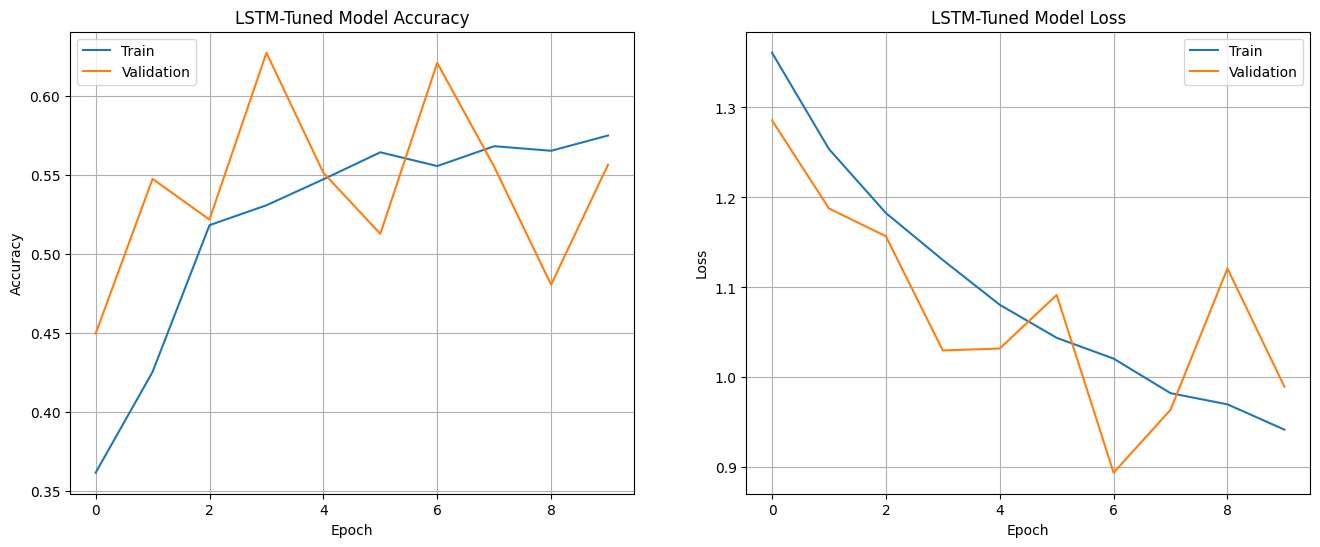

In [23]:
# Cell 12.5 (Insert after LSTM training)

print("--- Visualizing LSTM-Tuned Training History ---")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training & validation accuracy values
ax1.plot(history_lstm_1.history['accuracy'])
ax1.plot(history_lstm_1.history['val_accuracy'])
ax1.set_title('LSTM-Tuned Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')
ax1.grid(True)


# Plot training & validation loss values
ax2.plot(history_lstm_1.history['loss'])
ax2.plot(history_lstm_1.history['val_loss'])
ax2.set_title('LSTM-Tuned Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper right')
ax2.grid(True)

plt.show()

# Based on the plots, we can discuss if the model overfitted and how EarlyStopping helped.
# For example, if val_loss started to increase after epoch 5, EarlyStopping would have
# restored the model weights from the end of epoch 5, giving us the best performing model.


--- Evaluating the LSTM Model ---
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

LSTM-Tuned Classification Report:
              precision    recall  f1-score   support

    negative       0.38      0.47      0.42       125
     neutral       0.67      0.92      0.77       565
    positive       0.53      0.07      0.13       280

    accuracy                           0.62       970
   macro avg       0.52      0.49      0.44       970
weighted avg       0.59      0.62      0.54       970



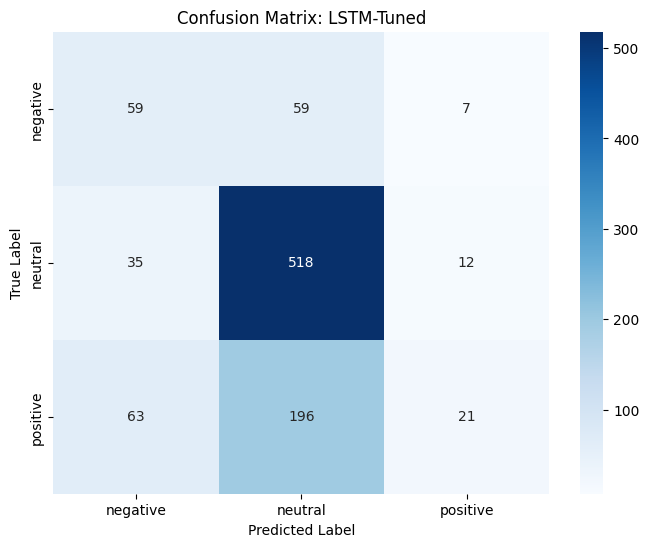

In [24]:
# Cell 17 (Corrected)
print("\n--- Evaluating the LSTM Model ---")

# --- Step 1: Convert the test data to the same tf.data.Dataset format ---
# We do not shuffle the test set. We just batch it.
test_dataset_lstm = tf.data.Dataset.from_tensor_slices(X_test.values)
test_dataset_lstm = test_dataset_lstm.batch(32).prefetch(tf.data.AUTOTUNE)

# --- Step 2: Predict using the batched dataset ---
y_pred_probs_lstm_1 = model_lstm_1.predict(test_dataset_lstm)
y_pred_lstm_1 = np.argmax(y_pred_probs_lstm_1, axis=1)

# --- Step 3: Evaluate the results (this part remains the same) ---
print("\nLSTM-Tuned Classification Report:")
print(classification_report(y_test, y_pred_lstm_1, target_names=label_map.values()))
plot_confusion_matrix(y_test, y_pred_lstm_1, "Confusion Matrix: LSTM-Tuned")
results['LSTM-Tuned'] = f1_score(y_test, y_pred_lstm_1, average='macro')

In [25]:
# Cell 14
from transformers.optimization_tf import create_optimizer
print("--- Preparing Model 4: Transformer (FinBERT) ---")
model_name = "ProsusAI/finbert"
finbert_tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize data for BERT
train_encodings = finbert_tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
val_encodings = finbert_tokenizer(list(X_val), truncation=True, padding=True, max_length=128)
test_encodings = finbert_tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), y_train))
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_encodings), y_val))
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), y_test))

# Load the model
finbert_model = TFAutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

# Set up the recommended AdamW optimizer with learning rate scheduling
num_epochs = 3
batch_size = 32
num_train_steps = (len(train_df) // batch_size) * num_epochs
optimizer, _ = create_optimizer(init_lr=5e-5, num_warmup_steps=0, num_train_steps=num_train_steps)

finbert_model.compile(optimizer=optimizer, loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
print("FinBERT model and optimizer are ready.")

--- Preparing Model 4: Transformer (FinBERT) ---


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/438M [00:00<?, ?B/s]

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at ProsusAI/finbert and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


FinBERT model and optimizer are ready.



--- Fine-tuning and Evaluating FinBERT ---
Epoch 1/3


I0000 00:00:1753599917.214080      69 service.cc:148] XLA service 0x7a594ce6adc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753599917.215281      69 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1753599917.215302      69 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1753599917.504824      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


97/97 [==============================] - 139s 908ms/step - loss: 0.4687 - accuracy: 0.8090 - val_loss: 0.3148 - val_accuracy: 0.8763
Epoch 2/3
97/97 [==============================] - 83s 852ms/step - loss: 0.1875 - accuracy: 0.9371 - val_loss: 0.2984 - val_accuracy: 0.8879
Epoch 3/3
97/97 [==============================] - 82s 849ms/step - loss: 0.0881 - accuracy: 0.9761 - val_loss: 0.3090 - val_accuracy: 0.8918

Evaluating fine-tuned FinBERT model on the Test Set...
31/31 [==============================] - 12s 262ms/step

FinBERT Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.91      0.85       125
     neutral       0.90      0.89      0.90       565
    positive       0.84      0.82      0.83       280

    accuracy                           0.87       970
   macro avg       0.85      0.87      0.86       970
weighted avg       0.87      0.87      0.87       970



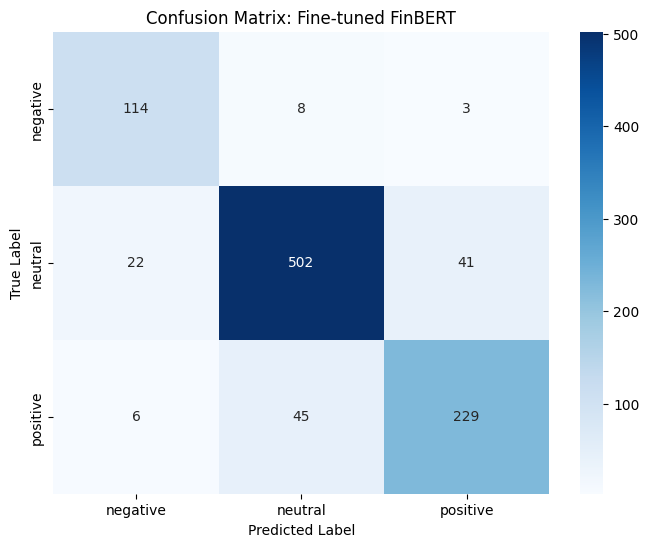

In [26]:
# Cell 15
print("\n--- Fine-tuning and Evaluating FinBERT ---")

# Fine-tune the model
history_finbert = finbert_model.fit(
    train_dataset.shuffle(1000).batch(batch_size),
    epochs=num_epochs,
    validation_data=val_dataset.batch(batch_size)
)

# Evaluate the model
print("\nEvaluating fine-tuned FinBERT model on the Test Set...")
pred_logits = finbert_model.predict(test_dataset.batch(batch_size)).logits
y_pred_finbert = np.argmax(pred_logits, axis=1)

print("\nFinBERT Classification Report:")
print(classification_report(y_test, y_pred_finbert, target_names=label_map.values()))
plot_confusion_matrix(y_test, y_pred_finbert, "Confusion Matrix: Fine-tuned FinBERT")
results['FinBERT'] = f1_score(y_test, y_pred_finbert, average='macro')

--- Visualizing FinBERT Fine-Tuning History ---


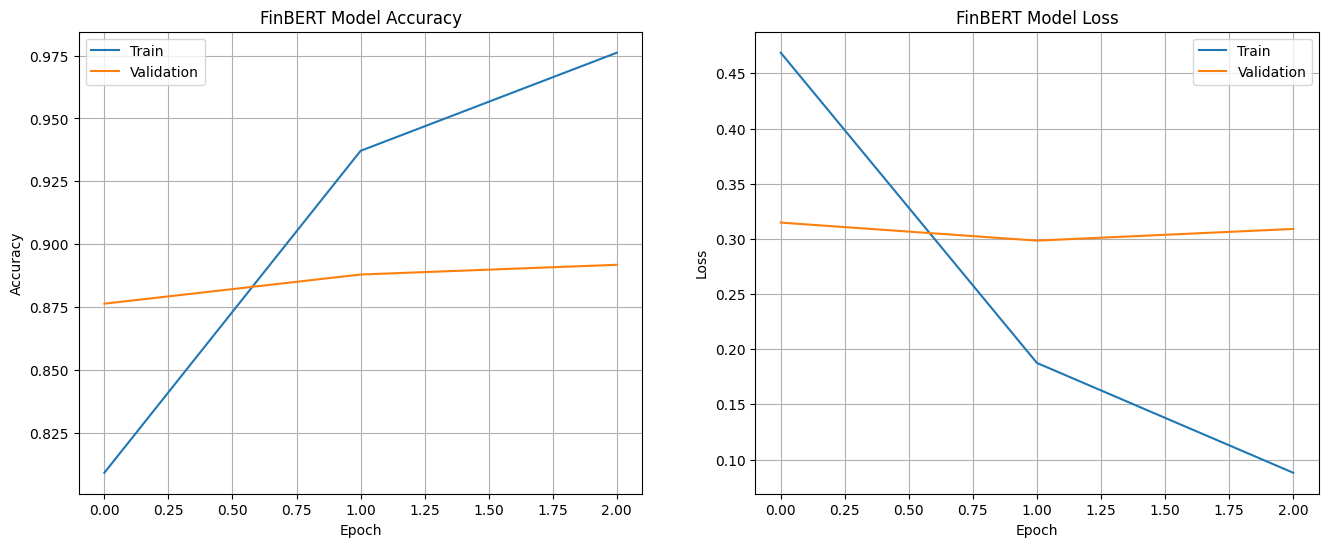

In [27]:
# Cell 15.5 (Insert after FinBERT training and evaluation)

print("--- Visualizing FinBERT Fine-Tuning History ---")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training & validation accuracy values
ax1.plot(history_finbert.history['accuracy'])
ax1.plot(history_finbert.history['val_accuracy'])
ax1.set_title('FinBERT Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')
ax1.grid(True)

# Plot training & validation loss values
ax2.plot(history_finbert.history['loss'])
ax2.plot(history_finbert.history['val_loss'])
ax2.set_title('FinBERT Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper right')
ax2.grid(True)

plt.show()

# The plots will likely show the training loss decreasing sharply while the validation loss
# flattens out very quickly. This is classic behavior during fine-tuning and confirms that
# training for only a few epochs with EarlyStopping was the correct strategy.


--- Final Model Comparison ---
             Macro F1-Score
FinBERT            0.859524
SVM                0.676317
Naive Bayes        0.608004
LSTM               0.560526
LSTM-Tuned         0.441327


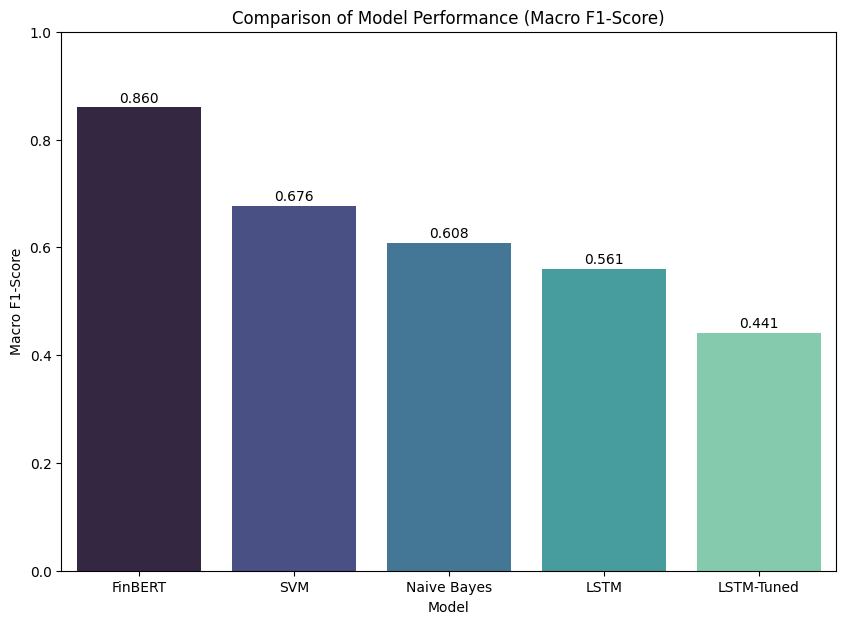

In [28]:
# Cell 16
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1-Score'])
results_df = results_df.sort_values(by='Macro F1-Score', ascending=False)

print("\n--- Final Model Comparison ---")
print(results_df)

# Create the final comparison plot
plt.figure(figsize=(10, 7))
sns.barplot(x=results_df.index, y=results_df['Macro F1-Score'], palette='mako')
plt.title('Comparison of Model Performance (Macro F1-Score)')
plt.xlabel('Model')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
for index, value in enumerate(results_df['Macro F1-Score']):
    plt.text(index, value + 0.01, f"{value:.3f}", ha='center')
plt.show()

In [29]:
print("--- Preparing DataFrame for Error Analysis ---")

# Create a new DataFrame for analysis
error_analysis_df = test_df.copy()
error_analysis_df['predicted_label_id'] = y_pred_finbert
error_analysis_df['predicted_label_name'] = error_analysis_df['predicted_label_id'].map(label_map)
error_analysis_df['true_label_name'] = error_analysis_df['label'].map(label_map)
error_analysis_df['is_correct'] = (error_analysis_df['label'] == error_analysis_df['predicted_label_id'])

print(f"Number of correct predictions: {error_analysis_df['is_correct'].sum()}")
print(f"Number of incorrect predictions: {len(error_analysis_df) - error_analysis_df['is_correct'].sum()}")

# Display the first few rows with the new columns
error_analysis_df

--- Preparing DataFrame for Error Analysis ---
Number of correct predictions: 845
Number of incorrect predictions: 125


,sentence,label,predicted_label_id,predicted_label_name,true_label_name,is_correct
0,The works will include the laying of natural s...,1,1,neutral,neutral,True
1,Teleste has some 30 offices worldwide and is l...,1,1,neutral,neutral,True
2,Officials did not disclose the contract value .,1,1,neutral,neutral,True
3,`` Rapala is excited to be partnering with RBF...,1,2,positive,neutral,False
4,L&T 's net profit for the whole 2010 dropped t...,0,0,negative,negative,True
...,...,...,...,...,...,...
965,The report goes on to provide detailed profile...,1,1,neutral,neutral,True
966,Sanoma Magazines International will invite oth...,1,1,neutral,neutral,True
967,"On the other hand , Finnish sawmills ' product...",0,0,negative,negative,True
968,The dividends payable annually shall be deduct...,1,1,neutral,neutral,True
